Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: (2838, 11)

First few rows:
         Hotel name       Reviewer Name           Rating  \
0  Veriu Camperdown  Verified traveller        8/10 Good   
1  Veriu Camperdown  Verified traveller  10/10 Excellent   
2  Veriu Camperdown           Shinkichi  10/10 Excellent   
3  Veriu Camperdown                Nick  10/10 Excellent   
4  Veriu Camperdown              Carlos  10/10 Excellent   

                    Traveller Type       Date of Review  \
0            Travelled with family  2025-08-16 00:00:00   
1               Business traveller  2025-07-04 00:00:00   
2                              NaN  2025-08-20 00:00:00   
3             Travelled with group  2025-04-17 00:00:00   
4  Business traveller, with family  2025-04-30 00:00:00   

                                               Liked Disliked  \
0           cleanliness, c

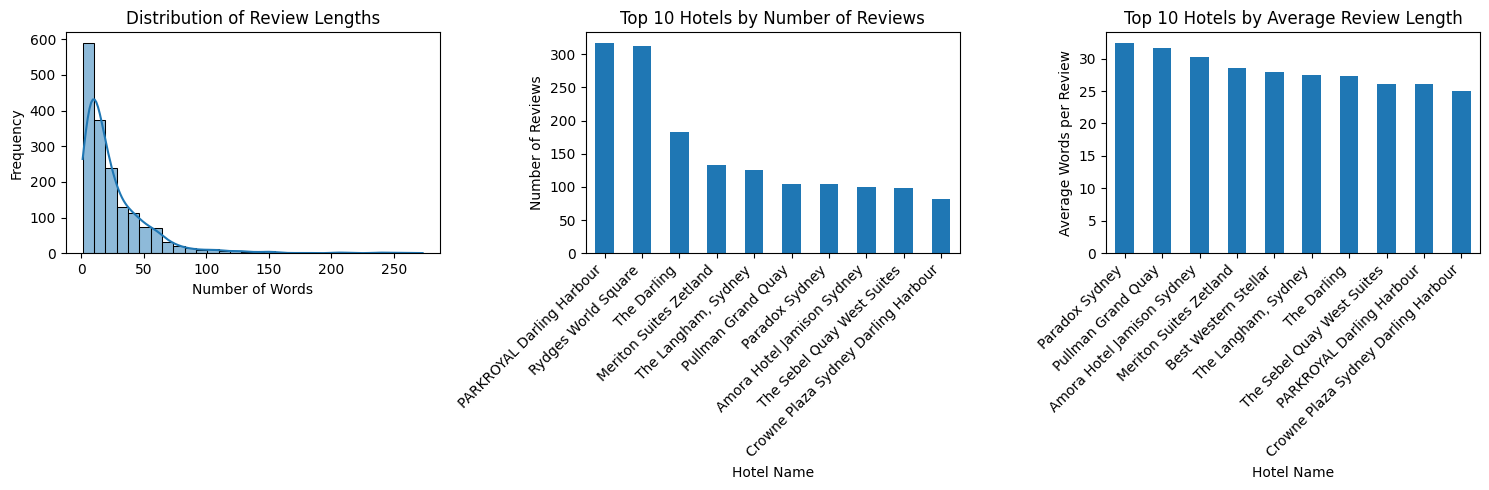


Top 20 most common words:
the: 2428
and: 1971
was: 1251
to: 1213
a: 1081
great: 689
in: 623
staff: 603
very: 602
room: 580
location: 554
stay: 538
we: 537
for: 523
is: 500
hotel: 492
of: 474
it: 469
i: 458
were: 407

Hotel review statistics:
Mean reviews per hotel: 132.08
Max reviews for a hotel: 317.0
Min reviews for a hotel: 40.0

VADER SENTIMENT ANALYSIS

Sentiment Distribution:
Positive reviews (1): 1477
Negative reviews (0): 240


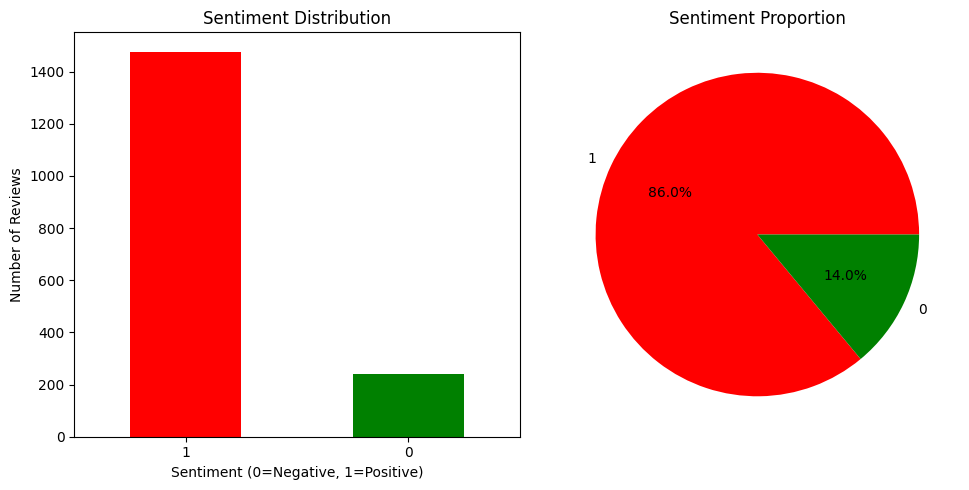


Top 10 Hotels by Number of Reviews with Sentiment:
                                     total_reviews  positive_ratio
Hotel name                                                        
PARKROYAL Darling Harbour                      317           0.864
Rydges World Square                            312           0.785
The Darling                                    183           0.902
Meriton Suites Zetland                         133           0.880
The Langham, Sydney                            126           0.921
Paradox Sydney                                 104           0.875
Pullman Grand Quay                             104           0.846
Amora Hotel Jamison Sydney                     100           0.850
The Sebel Quay West Suites                      99           0.949
Crowne Plaza Sydney Darling Harbour             82           0.841

Top 10 Hotels with Highest Positive Sentiment (min 5 reviews):
                            total_reviews  positive_ratio
Hotel name            

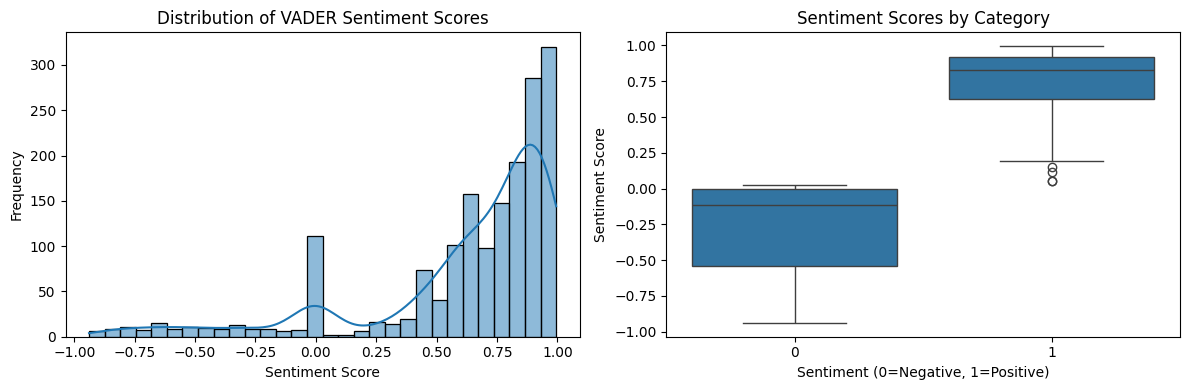


Analysis complete! ✅
Total reviews analyzed: 1717
Positive reviews: 1477 (86.0%)
Negative reviews: 240 (14.0%)

EXAMPLE REVIEWS

🌟 Example POSITIVE Reviews (Score > 0.5):

Score: 0.747
Review: very old property that could do with some sprucing up check in was very easy and good central location for exploring room was small very basic amenities and not the cleanest toilet bowl on the outside...

Score: 0.625
Review: great view facilities were average...

Score: 0.961
Review: amazing decor service wonderful comfy room and great bathroom pool on the roof a bonus sweets in the lobby were eaten...

⚠️ Example NEGATIVE Reviews (Score < -0.1):

Score: -0.931
Review: 2nd time staying in the exact same two bedroom apartment really like the apartment but some upgrading works need to be done i e kitchen drawer front falling off toilet lock faulty faucet in bathroom l...

Score: -0.224
Review: always stay here and can never fault their beautiful staff...

Score: -0.782
Review: one thing i did not

In [7]:

# Install required packages
!pip install vaderSentiment langdetect num2words
!pip install openpyxl  # for Excel file handling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect, DetectorFactory
import re
from num2words import num2words
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

# Set random seed for langdetect consistency
DetectorFactory.seed = 0

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the data - Updated path for Colab Notebooks folder
file_path = '/content/drive/MyDrive/Colab Notebooks/hotel.xlsx'
df = pd.read_excel(file_path)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Data Cleaning Function
def clean_review_data(df):
    """
    Comprehensive cleaning function for hotel review data
    """
    # Create a copy to avoid modifying original data
    clean_df = df.copy()

    # 0. Drop irrelevant columns (like the empty 'Unnamed: 10')
    print("Dropping irrelevant columns...")
    cols_to_drop = ['Unnamed: 10']
    clean_df = clean_df.drop(columns=cols_to_drop, errors='ignore')
    print(f"Dropped columns: {cols_to_drop}")


    # 1. Handle missing values
    print("Handling missing values...")
    initial_count = len(clean_df)
    clean_df = clean_df.dropna(subset=['Review Summary'])
    print(f"Removed {initial_count - len(clean_df)} rows with missing reviews")

    # 2. Remove duplicates
    initial_count = len(clean_df)
    clean_df = clean_df.drop_duplicates(subset=['Review Summary'])
    print(f"Removed {initial_count - len(clean_df)} duplicate reviews")

    # 3. Language detection and filtering (English only)
    print("Filtering English reviews...")

    def is_english(text):
        try:
            return detect(str(text)) == 'en'
        except:
            return False

    initial_count = len(clean_df)
    clean_df = clean_df[clean_df['Review Summary'].apply(is_english)]
    print(f"Removed {initial_count - len(clean_df)} non-English reviews")

    # 4. Convert to lowercase
    clean_df['Review Summary'] = clean_df['Review Summary'].str.lower()

    # 5. Handle common abbreviations
    print("Handling abbreviations...")
    abbreviation_map = {
        r'\bbr\b': 'bathroom',
        r'\bw\/': 'with',
        r'\bw\/o\b': 'without',
        r'\brm\b': 'room',
        r'\bbf\b': 'breakfast',
        r'\bac\b': 'air conditioning',
        r'\bwifi\b': 'wi-fi',
        r'\btv\b': 'television',
        r'\bmin\b': 'minute',
        r'\bhr\b': 'hour',
        r'\bstd\b': 'standard',
        r'\bdelux\b': 'deluxe',
        r'\bapt\b': 'apartment',
        r'\bavail\b': 'available',
        r'\bapprox\b': 'approximately',
        r'\bbldg\b': 'building',
        r'\bloc\b': 'location',
        r'\bexcel\b': 'excellent',
        r'\bamt\b': 'amount',
        r'\basap\b': 'as soon as possible',
        r'\beth\b': 'et cetera',
    }

    for abbrev, full_form in abbreviation_map.items():
        clean_df['Review Summary'] = clean_df['Review Summary'].str.replace(abbrev, full_form, regex=True)

    # 6. Convert numbers to words
    print("Converting numbers to words...")

    def convert_numbers(text):
        def num_to_word(match):
            num = match.group()
            try:
                return num2words(int(num))
            except:
                return num

        return re.sub(r'\b\d+\b', num_to_word, text)

    clean_df['Review Summary'] = clean_df['Review Summary'].apply(convert_numbers)

    # 7. Additional cleaning
    clean_df['Review Summary'] = clean_df['Review Summary'].str.replace(r'[^\w\s]', ' ', regex=True)  # Remove special chars
    clean_df['Review Summary'] = clean_df['Review Summary'].str.replace(r'\s+', ' ', regex=True)  # Remove extra spaces
    clean_df['Review Summary'] = clean_df['Review Summary'].str.strip()  # Trim whitespace

    print(f"Final dataset size: {len(clean_df)} reviews")
    return clean_df

# Apply cleaning
cleaned_df = clean_review_data(df)

# EDA Function
def perform_eda(cleaned_df):
    """
    Perform exploratory data analysis on cleaned data
    """
    print("=" * 50)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 50)

    # Basic statistics
    print(f"Total hotels: {cleaned_df['Hotel name'].nunique()}")
    print(f"Total reviews: {len(cleaned_df)}")

    # Review length analysis
    cleaned_df['review_length'] = cleaned_df['Review Summary'].apply(lambda x: len(x.split()))

    plt.figure(figsize=(15, 5))

    # Review length distribution
    plt.subplot(1, 3, 1)
    sns.histplot(cleaned_df['review_length'], bins=30, kde=True)
    plt.title('Distribution of Review Lengths')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')

    # Top hotels by number of reviews
    plt.subplot(1, 3, 2)
    top_hotels = cleaned_df['Hotel name'].value_counts().head(10)
    top_hotels.plot(kind='bar')
    plt.title('Top 10 Hotels by Number of Reviews')
    plt.xlabel('Hotel Name')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=45, ha='right')

    # Average review length by hotel
    plt.subplot(1, 3, 3)
    avg_length = cleaned_df.groupby('Hotel name')['review_length'].mean().sort_values(ascending=False).head(10)
    avg_length.plot(kind='bar')
    plt.title('Top 10 Hotels by Average Review Length')
    plt.xlabel('Hotel Name')
    plt.ylabel('Average Words per Review')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    # Word frequency analysis
    from collections import Counter
    all_words = ' '.join(cleaned_df['Review Summary']).split()
    word_freq = Counter(all_words)

    print("\nTop 20 most common words:")
    for word, count in word_freq.most_common(20):
        print(f"{word}: {count}")

    # Hotel statistics
    hotel_stats = cleaned_df['Hotel name'].value_counts().describe()
    print(f"\nHotel review statistics:")
    print(f"Mean reviews per hotel: {hotel_stats['mean']:.2f}")
    print(f"Max reviews for a hotel: {hotel_stats['max']}")
    print(f"Min reviews for a hotel: {hotel_stats['min']}")

    return cleaned_df

# Perform EDA
final_df = perform_eda(cleaned_df)

# VADER Sentiment Analysis
print("\n" + "=" * 50)
print("VADER SENTIMENT ANALYSIS")
print("=" * 50)

# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment_analysis(text):
    """
    Perform sentiment analysis using VADER and return compound score
    """
    sentiment_scores = analyzer.polarity_scores(str(text))
    return sentiment_scores['compound']

# Apply VADER sentiment analysis
final_df['sentiment_score'] = final_df['Review Summary'].apply(vader_sentiment_analysis)

# Categorize sentiment: 1 for positive, 0 for negative
def categorize_sentiment(score):
    """
    Categorize sentiment based on VADER compound score
    """
    if score >= 0.05:  # Positive sentiment threshold
        return 1  # Positive
    else:  # Negative or neutral (<= 0.05)
        return 0  # Negative

final_df['sentiment'] = final_df['sentiment_score'].apply(categorize_sentiment)

# Sentiment Analysis Results
print("\nSentiment Distribution:")
sentiment_counts = final_df['sentiment'].value_counts()
print(f"Positive reviews (1): {sentiment_counts.get(1, 0)}")
print(f"Negative reviews (0): {sentiment_counts.get(0, 0)}")

# Visualize sentiment distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sentiment_counts.plot(kind='bar', color=['red', 'green'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
sentiment_counts.plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Sentiment Proportion')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Hotel-wise sentiment analysis
hotel_sentiment = final_df.groupby('Hotel name')['sentiment'].agg(['count', 'mean']).round(3)
hotel_sentiment.columns = ['total_reviews', 'positive_ratio']
hotel_sentiment = hotel_sentiment.sort_values('total_reviews', ascending=False)

print("\nTop 10 Hotels by Number of Reviews with Sentiment:")
print(hotel_sentiment.head(10))

# Hotels with highest positive sentiment (min 5 reviews)
min_reviews = 5
qualified_hotels = hotel_sentiment[hotel_sentiment['total_reviews'] >= min_reviews]
top_positive_hotels = qualified_hotels.sort_values('positive_ratio', ascending=False).head(10)

print(f"\nTop 10 Hotels with Highest Positive Sentiment (min {min_reviews} reviews):")
print(top_positive_hotels)

# Hotels with lowest positive sentiment (min 5 reviews)
top_negative_hotels = qualified_hotels.sort_values('positive_ratio', ascending=True).head(10)

print(f"\nTop 10 Hotels with Lowest Positive Sentiment (min {min_reviews} reviews):")
print(top_negative_hotels)

# Save results with sentiment analysis - also in Colab Notebooks folder
output_path = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_with_sentiment.xlsx'
final_df.to_excel(output_path, index=False)
print(f"\nResults saved to: {output_path}")

# Sample of reviews with their sentiment
print("\nSample of Reviews with Sentiment Analysis:")
sample_reviews = final_df[['Hotel name', 'Review Summary', 'sentiment_score', 'sentiment']].sample(10)
print(sample_reviews)

# Detailed analysis of sentiment scores
print("\nSentiment Score Statistics:")
print(final_df['sentiment_score'].describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(final_df['sentiment_score'], bins=30, kde=True)
plt.title('Distribution of VADER Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(x='sentiment', y='sentiment_score', data=final_df)
plt.title('Sentiment Scores by Category')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Sentiment Score')

plt.tight_layout()
plt.show()

print("\nAnalysis complete! ✅")
print(f"Total reviews analyzed: {len(final_df)}")
print(f"Positive reviews: {sentiment_counts.get(1, 0)} ({(sentiment_counts.get(1, 0)/len(final_df)*100):.1f}%)")
print(f"Negative reviews: {sentiment_counts.get(0, 0)} ({(sentiment_counts.get(0, 0)/len(final_df)*100):.1f}%)")

# Additional: Show some example positive and negative reviews
print("\n" + "=" * 60)
print("EXAMPLE REVIEWS")
print("=" * 60)

print("\n🌟 Example POSITIVE Reviews (Score > 0.5):")
positive_examples = final_df[final_df['sentiment_score'] > 0.5].sample(3)
for idx, row in positive_examples.iterrows():
    print(f"\nScore: {row['sentiment_score']:.3f}")
    print(f"Review: {row['Review Summary'][:200]}...")

print("\n⚠️ Example NEGATIVE Reviews (Score < -0.1):")
negative_examples = final_df[final_df['sentiment_score'] < -0.1].sample(3)
for idx, row in negative_examples.iterrows():
    print(f"\nScore: {row['sentiment_score']:.3f}")
    print(f"Review: {row['Review Summary'][:200]}...")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: (2838, 11)

First few rows:
         Hotel name       Reviewer Name           Rating  \
0  Veriu Camperdown  Verified traveller        8/10 Good   
1  Veriu Camperdown  Verified traveller  10/10 Excellent   
2  Veriu Camperdown           Shinkichi  10/10 Excellent   
3  Veriu Camperdown                Nick  10/10 Excellent   
4  Veriu Camperdown              Carlos  10/10 Excellent   

                    Traveller

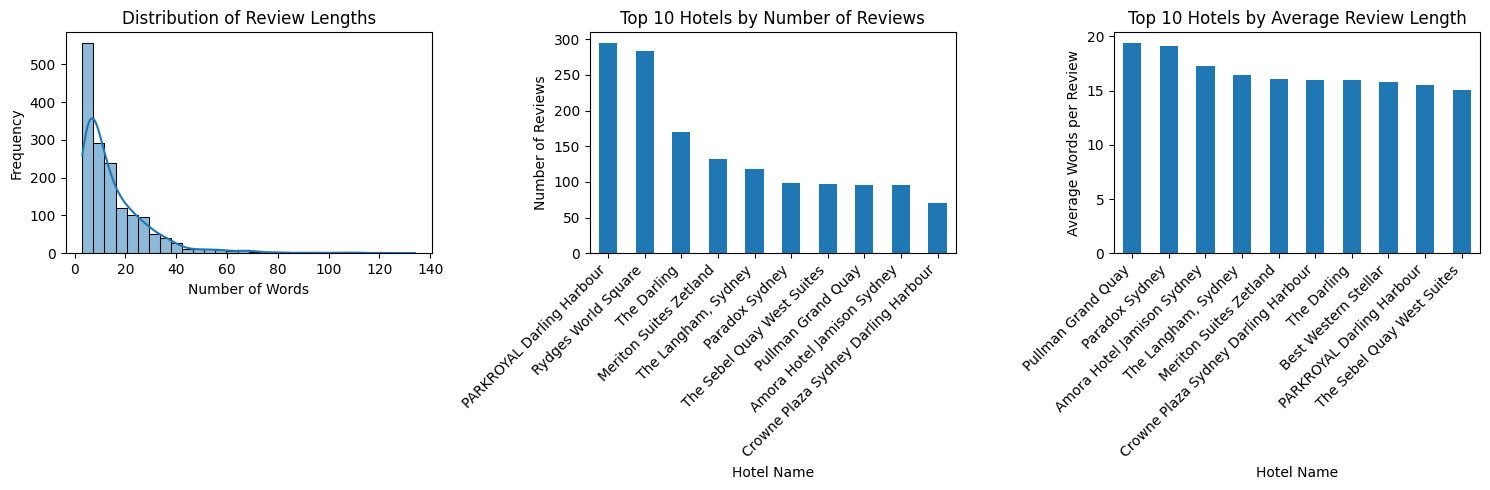


Top 20 most common words:
good: 1312
room: 744
stay: 658
staff: 602
location: 545
hotel: 515
excellent: 283
clean: 267
friendly: 261
service: 260
breakfast: 222
helpful: 210
would: 192
comfortable: 186
bed: 166
walk: 152
sydney: 143
close: 141
need: 139
one: 136

Hotel review statistics:
Mean reviews per hotel: 123.15
Max reviews for a hotel: 295.0
Min reviews for a hotel: 37.0

VADER SENTIMENT ANALYSIS

Sentiment Distribution:
Positive reviews (1): 1435
Negative reviews (0): 166


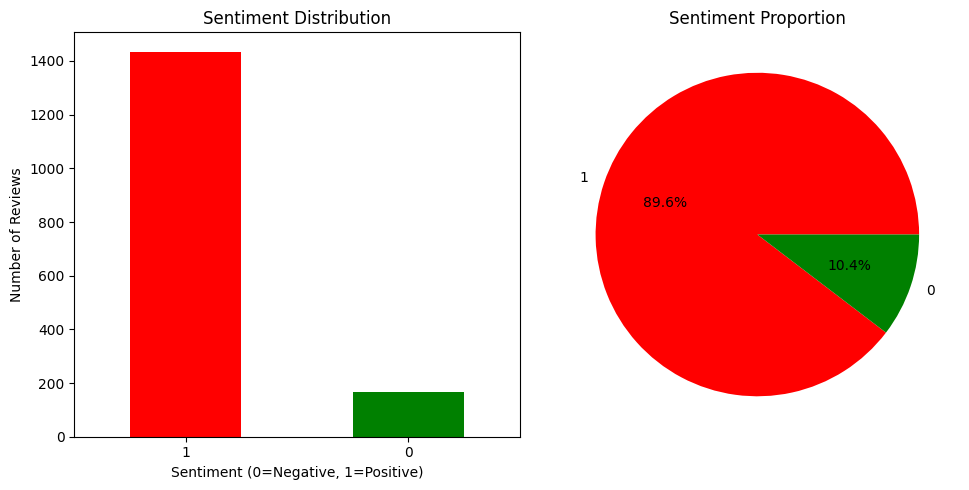


Top 10 Hotels by Number of Reviews with Sentiment:
                            total_reviews  positive_ratio
Hotel name                                               
PARKROYAL Darling Harbour             295           0.895
Rydges World Square                   283           0.823
The Darling                           170           0.953
Meriton Suites Zetland                132           0.894
The Langham, Sydney                   118           0.924
Paradox Sydney                         98           0.918
The Sebel Quay West Suites             97           0.959
Amora Hotel Jamison Sydney             96           0.865
Pullman Grand Quay                     96           0.917
Best Western Stellar                   71           0.887

Top 10 Hotels with Highest Positive Sentiment (min 5 reviews):
                                     total_reviews  positive_ratio
Hotel name                                                        
The Old Clare Hotel                             37    

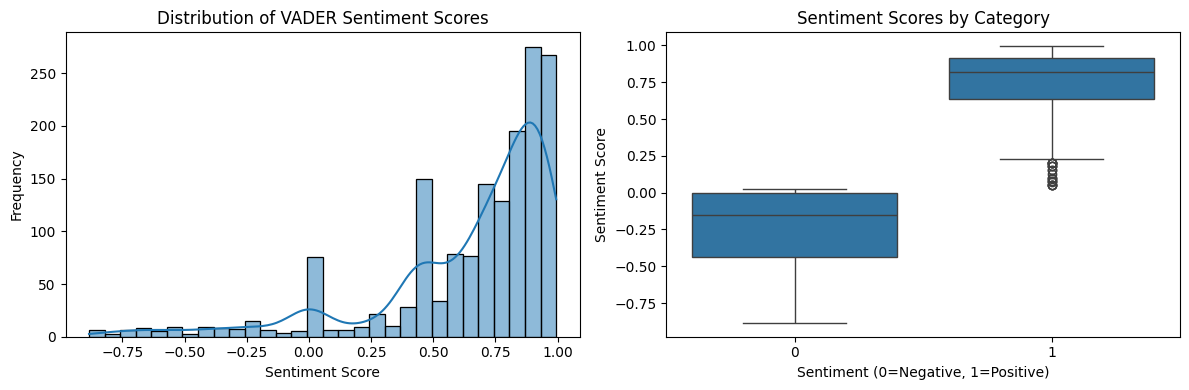


Analysis complete! ✅
Total reviews analyzed: 1601
Positive reviews: 1435 (89.6%)
Negative reviews: 166 (10.4%)

EXAMPLE REVIEWS

🌟 Example POSITIVE Reviews (Score > 0.5):

Score: 0.863
Review: crown plaza good staff go top need something friendly help get handy cap taxie...

Score: 0.936
Review: actual stay staff good book upgrade room already pay receive email place say could upgrade arrive ask would like upgrade plan email decline already upgrade check tell still pay upgrade say decline upg...

Score: 0.881
Review: well run hotel spacious room good spa bath bathroom comfortable although prefer turn ny head watch television bed food restaurant good fast room service...

⚠️ Example NEGATIVE Reviews (Score < -0.1):

Score: -0.758
Review: bad experience hotel especially front desk borderline rude condescending...

Score: -0.273
Review: good breakfast amenity centrally locate close transportation confusion room cleaning cause stress...

Score: -0.421
Review: many maintenance issue nail c

In [2]:
# -*- coding: utf-8 -*-
"""Advanced NLP Data Cleaning for Hotel Reviews with VADER Sentiment Analysis.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1_your_drive_link_here
"""

# Install required packages
!pip install vaderSentiment langdetect num2words spacy textblob nltk contractions emot clean-text
!pip install openpyxl  # for Excel file handling
!python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import contractions
from emot.emo_unicode import EMOTICONS_EMO
from cleantext import clean
from langdetect import detect, DetectorFactory
from num2words import num2words
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources with explicit download commands
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except:
    print("NLTK downloads completed")

# Set random seed for langdetect consistency
DetectorFactory.seed = 0

# Initialize NLP tools
try:
    nlp = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the data - Updated path for Colab Notebooks folder
file_path = '/content/drive/MyDrive/Colab Notebooks/hotel.xlsx'
df = pd.read_excel(file_path)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Advanced NLP Cleaning Functions
def handle_emojis_emoticons(text):
    """Convert emojis and emoticons to text descriptions"""
    # Handle emoticons
    for emot, desc in EMOTICONS_EMO.items():
        text = text.replace(emot, f" {desc} ")

    # Handle common emojis (simplified)
    emoji_map = {
        '😊': 'smiling face', '😂': 'laughing', '😍': 'heart eyes',
        '😎': 'cool', '😢': 'crying', '😡': 'angry', '👍': 'thumbs up',
        '👎': 'thumbs down', '❤️': 'heart', '⭐': 'star'
    }

    for emoji, desc in emoji_map.items():
        text = text.replace(emoji, f" {desc} ")

    return text

def remove_special_patterns(text):
    """Remove URLs, emails, phone numbers"""
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}', '', text)
    return text

def handle_abbreviations_slang(text):
    """Expand common abbreviations and handle slang"""
    abbreviation_map = {
        r'\bbr\b': 'bathroom', r'\bw\/': 'with', r'\bw\/o\b': 'without',
        r'\brm\b': 'room', r'\bbf\b': 'breakfast', r'\bac\b': 'air conditioning',
        r'\bwifi\b': 'wi-fi', r'\btv\b': 'television', r'\bmin\b': 'minute',
        r'\bhr\b': 'hour', r'\bstd\b': 'standard', r'\bdelux\b': 'deluxe',
        r'\bapt\b': 'apartment', r'\bavail\b': 'available', r'\bapprox\b': 'approximately',
        r'\basap\b': 'as soon as possible', r'\bpls\b': 'please', r'\bthx\b': 'thanks',
        r'\bgr8\b': 'great', r'\bbtw\b': 'by the way', r'\bimo\b': 'in my opinion',
        r'\bomg\b': 'oh my god', r'\blol\b': 'laugh out loud'
    }

    slang_map = {
        r'\bawesome\b': 'excellent', r'\bamazing\b': 'very good', r'\bterrible\b': 'very bad',
        r'\bawful\b': 'very bad', r'\bfantastic\b': 'excellent', r'\bhorrible\b': 'very bad',
        r'\bgreat\b': 'good', r'\bnice\b': 'good', r'\bpoor\b': 'bad'
    }

    for pattern, replacement in abbreviation_map.items():
        text = re.sub(pattern, replacement, text)

    for pattern, replacement in slang_map.items():
        text = re.sub(pattern, replacement, text)

    return text

def convert_numbers_to_words(text):
    """Convert numbers to words with context awareness"""
    def num_to_word(match):
        num_str = match.group()
        try:
            # Handle different number formats
            if '.' in num_str:
                num = float(num_str)
                return f"{num2words(int(num))} point {num2words(int((num - int(num)) * 100))}"
            else:
                num = int(num_str)
                return num2words(num)
        except:
            return num_str

    text = re.sub(r'\b\d+\.?\d*\b', num_to_word, text)
    return text

def clean_special_characters(text):
    """Remove special characters but keep meaningful punctuation"""
    # Keep basic punctuation that adds meaning
    text = re.sub(r'[^\w\s\.\!\?\,]', ' ', text)
    # Handle multiple punctuation
    text = re.sub(r'[\!\.\?]{2,}', '.', text)
    return text

def advanced_lemmatization(tokens):
    """Advanced lemmatization with POS tagging"""
    try:
        # Use spaCy for more reliable POS tagging
        doc = nlp(" ".join(tokens))
        lemmatized_tokens = []

        for token in doc:
            if token.pos_ == 'VERB':
                lemma = lemmatizer.lemmatize(token.text, pos='v')
            elif token.pos_ == 'ADJ':
                lemma = lemmatizer.lemmatize(token.text, pos='a')
            elif token.pos_ == 'ADV':
                lemma = lemmatizer.lemmatize(token.text, pos='r')
            else:
                lemma = lemmatizer.lemmatize(token.text)

            lemmatized_tokens.append(lemma)

        return lemmatized_tokens
    except:
        # Fallback to simple lemmatization if spaCy fails
        return [lemmatizer.lemmatize(token) for token in tokens]

def extract_key_phrases(text):
    """Extract key phrases using spaCy"""
    try:
        doc = nlp(text)
        phrases = []

        # Extract noun phrases
        for chunk in doc.noun_chunks:
            if len(chunk.text.split()) > 1:  # Only multi-word phrases
                phrases.append(chunk.text)

        return phrases
    except:
        return []

def advanced_nlp_cleaning(text):
    """
    Comprehensive NLP-based cleaning pipeline
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Expand contractions
    text = contractions.fix(text)

    # 2. Convert to lowercase
    text = text.lower()

    # 3. Handle emojis and emoticons
    text = handle_emojis_emoticons(text)

    # 4. Remove URLs, emails, phone numbers
    text = remove_special_patterns(text)

    # 5. Handle abbreviations and slang
    text = handle_abbreviations_slang(text)

    # 6. Convert numbers to words
    text = convert_numbers_to_words(text)

    # 7. Remove special characters but keep meaningful punctuation
    text = clean_special_characters(text)

    # 8. Tokenize and remove stopwords
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]

    # 9. Lemmatization with POS tagging
    tokens = advanced_lemmatization(tokens)

    # 10. Remove short tokens and extra spaces
    tokens = [token for token in tokens if len(token) > 1]
    text = ' '.join(tokens)

    # 11. Final cleaning
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def advanced_data_cleaning_pipeline(df, text_column='Review Summary'):
    """
    Complete NLP-powered data cleaning pipeline
    """
    print("Starting advanced NLP data cleaning...")

    # Create a copy
    clean_df = df.copy()

    # 0. Drop irrelevant columns (like the empty 'Unnamed: 10')
    print("Dropping irrelevant columns...")
    cols_to_drop = ['Unnamed: 10']
    clean_df = clean_df.drop(columns=cols_to_drop, errors='ignore')
    print(f"Dropped columns: {cols_to_drop}")

    # 1. Handle missing values
    initial_count = len(clean_df)
    clean_df = clean_df.dropna(subset=[text_column])
    print(f"Removed {initial_count - len(clean_df)} rows with missing text")

    # 2. Remove duplicates
    initial_count = len(clean_df)
    clean_df = clean_df.drop_duplicates(subset=[text_column])
    print(f"Removed {initial_count - len(clean_df)} duplicate reviews")

    # 3. Language detection and filtering
    print("Filtering English reviews...")

    def is_english(text):
        try:
            return detect(str(text)) == 'en'
        except:
            return False

    initial_count = len(clean_df)
    clean_df = clean_df[clean_df[text_column].apply(is_english)]
    print(f"Removed {initial_count - len(clean_df)} non-English reviews")

    # 4. Apply advanced NLP cleaning
    print("Applying advanced NLP cleaning...")
    clean_df['cleaned_text'] = clean_df[text_column].apply(advanced_nlp_cleaning)

    # 5. Remove very short reviews after cleaning
    initial_count = len(clean_df)
    clean_df = clean_df[clean_df['cleaned_text'].str.split().str.len() > 2]
    print(f"Removed {initial_count - len(clean_df)} very short reviews")

    # 6. Extract key phrases for analysis
    print("Extracting key phrases...")
    clean_df['key_phrases'] = clean_df['cleaned_text'].apply(extract_key_phrases)

    print(f"Final dataset size: {len(clean_df)} reviews")
    return clean_df

# Apply advanced NLP cleaning
cleaned_df = advanced_data_cleaning_pipeline(df)

# EDA Function
def perform_eda(cleaned_df):
    """
    Perform exploratory data analysis on cleaned data
    """
    print("=" * 50)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 50)

    # Basic statistics
    print(f"Total hotels: {cleaned_df['Hotel name'].nunique()}")
    print(f"Total reviews: {len(cleaned_df)}")

    # Review length analysis
    cleaned_df['review_length'] = cleaned_df['cleaned_text'].apply(lambda x: len(x.split()))

    plt.figure(figsize=(15, 5))

    # Review length distribution
    plt.subplot(1, 3, 1)
    sns.histplot(cleaned_df['review_length'], bins=30, kde=True)
    plt.title('Distribution of Review Lengths')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')

    # Top hotels by number of reviews
    plt.subplot(1, 3, 2)
    top_hotels = cleaned_df['Hotel name'].value_counts().head(10)
    top_hotels.plot(kind='bar')
    plt.title('Top 10 Hotels by Number of Reviews')
    plt.xlabel('Hotel Name')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=45, ha='right')

    # Average review length by hotel
    plt.subplot(1, 3, 3)
    avg_length = cleaned_df.groupby('Hotel name')['review_length'].mean().sort_values(ascending=False).head(10)
    avg_length.plot(kind='bar')
    plt.title('Top 10 Hotels by Average Review Length')
    plt.xlabel('Hotel Name')
    plt.ylabel('Average Words per Review')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    # Word frequency analysis
    from collections import Counter
    all_words = ' '.join(cleaned_df['cleaned_text']).split()
    word_freq = Counter(all_words)

    print("\nTop 20 most common words:")
    for word, count in word_freq.most_common(20):
        print(f"{word}: {count}")

    # Hotel statistics
    hotel_stats = cleaned_df['Hotel name'].value_counts().describe()
    print(f"\nHotel review statistics:")
    print(f"Mean reviews per hotel: {hotel_stats['mean']:.2f}")
    print(f"Max reviews for a hotel: {hotel_stats['max']}")
    print(f"Min reviews for a hotel: {hotel_stats['min']}")

    return cleaned_df

# Perform EDA
final_df = perform_eda(cleaned_df)

# VADER Sentiment Analysis
print("\n" + "=" * 50)
print("VADER SENTIMENT ANALYSIS")
print("=" * 50)

# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment_analysis(text):
    """
    Perform sentiment analysis using VADER and return compound score
    """
    sentiment_scores = analyzer.polarity_scores(str(text))
    return sentiment_scores['compound']

# Apply VADER sentiment analysis on cleaned text
final_df['sentiment_score'] = final_df['cleaned_text'].apply(vader_sentiment_analysis)

# Categorize sentiment: 1 for positive, 0 for negative
def categorize_sentiment(score):
    """
    Categorize sentiment based on VADER compound score
    """
    if score >= 0.05:  # Positive sentiment threshold
        return 1  # Positive
    else:  # Negative or neutral (<= 0.05)
        return 0  # Negative

final_df['sentiment'] = final_df['sentiment_score'].apply(categorize_sentiment)

# Sentiment Analysis Results
print("\nSentiment Distribution:")
sentiment_counts = final_df['sentiment'].value_counts()
print(f"Positive reviews (1): {sentiment_counts.get(1, 0)}")
print(f"Negative reviews (0): {sentiment_counts.get(0, 0)}")

# Visualize sentiment distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sentiment_counts.plot(kind='bar', color=['red', 'green'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
sentiment_counts.plot(kind='pie', autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Sentiment Proportion')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Hotel-wise sentiment analysis
hotel_sentiment = final_df.groupby('Hotel name')['sentiment'].agg(['count', 'mean']).round(3)
hotel_sentiment.columns = ['total_reviews', 'positive_ratio']
hotel_sentiment = hotel_sentiment.sort_values('total_reviews', ascending=False)

print("\nTop 10 Hotels by Number of Reviews with Sentiment:")
print(hotel_sentiment.head(10))

# Hotels with highest positive sentiment (min 5 reviews)
min_reviews = 5
qualified_hotels = hotel_sentiment[hotel_sentiment['total_reviews'] >= min_reviews]
top_positive_hotels = qualified_hotels.sort_values('positive_ratio', ascending=False).head(10)

print(f"\nTop 10 Hotels with Highest Positive Sentiment (min {min_reviews} reviews):")
print(top_positive_hotels)

# Hotels with lowest positive sentiment (min 5 reviews)
top_negative_hotels = qualified_hotels.sort_values('positive_ratio', ascending=True).head(10)

print(f"\nTop 10 Hotels with Lowest Positive Sentiment (min {min_reviews} reviews):")
print(top_negative_hotels)

# Save results with sentiment analysis - also in Colab Notebooks folder
output_path = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_with_sentiment.xlsx'
final_df.to_excel(output_path, index=False)
print(f"\nResults saved to: {output_path}")

# Sample of reviews with their sentiment
print("\nSample of Reviews with Sentiment Analysis:")
sample_reviews = final_df[['Hotel name', 'cleaned_text', 'sentiment_score', 'sentiment']].sample(10)
print(sample_reviews)

# Detailed analysis of sentiment scores
print("\nSentiment Score Statistics:")
print(final_df['sentiment_score'].describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(final_df['sentiment_score'], bins=30, kde=True)
plt.title('Distribution of VADER Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(x='sentiment', y='sentiment_score', data=final_df)
plt.title('Sentiment Scores by Category')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Sentiment Score')

plt.tight_layout()
plt.show()

print("\nAnalysis complete! ✅")
print(f"Total reviews analyzed: {len(final_df)}")
print(f"Positive reviews: {sentiment_counts.get(1, 0)} ({(sentiment_counts.get(1, 0)/len(final_df)*100):.1f}%)")
print(f"Negative reviews: {sentiment_counts.get(0, 0)} ({(sentiment_counts.get(0, 0)/len(final_df)*100):.1f}%)")

# Additional: Show some example positive and negative reviews
print("\n" + "=" * 60)
print("EXAMPLE REVIEWS")
print("=" * 60)

print("\n🌟 Example POSITIVE Reviews (Score > 0.5):")
positive_examples = final_df[final_df['sentiment_score'] > 0.5].sample(3)
for idx, row in positive_examples.iterrows():
    print(f"\nScore: {row['sentiment_score']:.3f}")
    print(f"Review: {row['cleaned_text'][:200]}...")

print("\n⚠️ Example NEGATIVE Reviews (Score < -0.1):")
negative_examples = final_df[final_df['sentiment_score'] < -0.1].sample(3)
for idx, row in negative_examples.iterrows():
    print(f"\nScore: {row['sentiment_score']:.3f}")
    print(f"Review: {row['cleaned_text'][:200]}...")

In [5]:
# -*- coding: utf-8 -*-
"""NLP-Only Data Cleaning for Hotel Reviews with VADER Sentiment Analysis"""

# Install required packages
!pip install vaderSentiment langdetect num2words spacy textblob nltk contractions emot clean-text
!pip install openpyxl  # for Excel file handling
!python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import re
import spacy
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import contractions
from emot.emo_unicode import EMOTICONS_EMO
from cleantext import clean
from langdetect import detect, DetectorFactory
from num2words import num2words
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources with explicit download commands
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except:
    print("NLTK downloads completed")

# Set random seed for langdetect consistency
DetectorFactory.seed = 0

# Initialize NLP tools
try:
    nlp = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the data - Updated path for Colab Notebooks folder
file_path = '/content/drive/MyDrive/Colab Notebooks/hotel.xlsx'
df = pd.read_excel(file_path)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

# Advanced NLP Cleaning Functions
def handle_emojis_emoticons(text):
    """Convert emojis and emoticons to text descriptions"""
    # Handle emoticons
    for emot, desc in EMOTICONS_EMO.items():
        text = text.replace(emot, f" {desc} ")

    # Handle common emojis (simplified)
    emoji_map = {
        '😊': 'smiling face', '😂': 'laughing', '😍': 'heart eyes',
        '😎': 'cool', '😢': 'crying', '😡': 'angry', '👍': 'thumbs up',
        '👎': 'thumbs down', '❤️': 'heart', '⭐': 'star'
    }

    for emoji, desc in emoji_map.items():
        text = text.replace(emoji, f" {desc} ")

    return text

def remove_special_patterns(text):
    """Remove URLs, emails, phone numbers"""
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}', '', text)
    return text

def handle_abbreviations_slang(text):
    """Expand common abbreviations and handle slang"""
    abbreviation_map = {
        r'\bbr\b': 'bathroom', r'\bw\/': 'with', r'\bw\/o\b': 'without',
        r'\brm\b': 'room', r'\bbf\b': 'breakfast', r'\bac\b': 'air conditioning',
        r'\bwifi\b': 'wi-fi', r'\btv\b': 'television', r'\bmin\b': 'minute',
        r'\bhr\b': 'hour', r'\bstd\b': 'standard', r'\bdelux\b': 'deluxe',
        r'\bapt\b': 'apartment', r'\bavail\b': 'available', r'\bapprox\b': 'approximately',
        r'\basap\b': 'as soon as possible', r'\bpls\b': 'please', r'\bthx\b': 'thanks',
        r'\bgr8\b': 'great', r'\bbtw\b': 'by the way', r'\bimo\b': 'in my opinion',
        r'\bomg\b': 'oh my god', r'\blol\b': 'laugh out loud'
    }

    slang_map = {
        r'\bawesome\b': 'excellent', r'\bamazing\b': 'very good', r'\bterrible\b': 'very bad',
        r'\bawful\b': 'very bad', r'\bfantastic\b': 'excellent', r'\bhorrible\b': 'very bad',
        r'\bgreat\b': 'good', r'\bnice\b': 'good', r'\bpoor\b': 'bad'
    }

    for pattern, replacement in abbreviation_map.items():
        text = re.sub(pattern, replacement, text)

    for pattern, replacement in slang_map.items():
        text = re.sub(pattern, replacement, text)

    return text

def convert_numbers_to_words(text):
    """Convert numbers to words with context awareness"""
    def num_to_word(match):
        num_str = match.group()
        try:
            # Handle different number formats
            if '.' in num_str:
                num = float(num_str)
                return f"{num2words(int(num))} point {num2words(int((num - int(num)) * 100))}"
            else:
                num = int(num_str)
                return num2words(num)
        except:
            return num_str

    text = re.sub(r'\b\d+\.?\d*\b', num_to_word, text)
    return text

def clean_special_characters(text):
    """Remove special characters but keep meaningful punctuation"""
    # Keep basic punctuation that adds meaning
    text = re.sub(r'[^\w\s\.\!\?\,]', ' ', text)
    # Handle multiple punctuation
    text = re.sub(r'[\!\.\?]{2,}', '.', text)
    return text

def advanced_lemmatization(tokens):
    """Advanced lemmatization with POS tagging"""
    try:
        # Use spaCy for more reliable POS tagging
        doc = nlp(" ".join(tokens))
        lemmatized_tokens = []

        for token in doc:
            if token.pos_ == 'VERB':
                lemma = lemmatizer.lemmatize(token.text, pos='v')
            elif token.pos_ == 'ADJ':
                lemma = lemmatizer.lemmatize(token.text, pos='a')
            elif token.pos_ == 'ADV':
                lemma = lemmatizer.lemmatize(token.text, pos='r')
            else:
                lemma = lemmatizer.lemmatize(token.text)

            lemmatized_tokens.append(lemma)

        return lemmatized_tokens
    except:
        # Fallback to simple lemmatization if spaCy fails
        return [lemmatizer.lemmatize(token) for token in tokens]

def extract_key_phrases(text):
    """Extract key phrases using spaCy"""
    try:
        doc = nlp(text)
        phrases = []

        # Extract noun phrases
        for chunk in doc.noun_chunks:
            if len(chunk.text.split()) > 1:  # Only multi-word phrases
                phrases.append(chunk.text)

        return phrases
    except:
        return []

def advanced_nlp_cleaning(text):
    """
    Comprehensive NLP-based cleaning pipeline
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Expand contractions
    text = contractions.fix(text)

    # 2. Convert to lowercase
    text = text.lower()

    # 3. Handle emojis and emoticons
    text = handle_emojis_emoticons(text)

    # 4. Remove URLs, emails, phone numbers
    text = remove_special_patterns(text)

    # 5. Handle abbreviations and slang
    text = handle_abbreviations_slang(text)

    # 6. Convert numbers to words
    text = convert_numbers_to_words(text)

    # 7. Remove special characters but keep meaningful punctuation
    text = clean_special_characters(text)

    # 8. Tokenize and remove stopwords
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]

    # 9. Lemmatization with POS tagging
    tokens = advanced_lemmatization(tokens)

    # 10. Remove short tokens and extra spaces
    tokens = [token for token in tokens if len(token) > 1]
    text = ' '.join(tokens)

    # 11. Final cleaning
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Data quality filtering for Review Summary column
print("Filtering Review Summary data for quality...")

# Check if Review Summary column exists
if 'Review Summary' not in df.columns:
    print("Available columns:", df.columns.tolist())
    raise ValueError("Review Summary column not found in the dataset")

initial_count = len(df)
print(f"Initial dataset size: {initial_count} rows")

# 1. Remove rows where Review Summary is empty or NaN
print("Step 1: Removing empty Review Summary entries...")
df = df.dropna(subset=['Review Summary'])
df = df[df['Review Summary'].str.strip() != '']
print(f"After removing empty entries: {len(df)} rows (removed {initial_count - len(df)} rows)")

# 2. Filter for English language only
print("Step 2: Filtering for English language only...")
def is_english_and_meaningful(text):
    """Check if text is in English and meaningful"""
    try:
        text = str(text).strip()

        # Check minimum length
        if len(text.split()) < 2:  # At least 2 words
            return False

        # Check if it's English
        detected_lang = detect(text)
        if detected_lang != 'en':
            return False

        # Check for meaningful content (not just numbers, symbols, or gibberish)
        # Remove common non-meaningful patterns
        cleaned_for_check = re.sub(r'[^\w\s]', '', text.lower())
        words = cleaned_for_check.split()

        # Filter out if mostly numbers or single characters
        meaningful_words = [w for w in words if len(w) > 1 and not w.isdigit()]
        if len(meaningful_words) < 2:
            return False

        return True
    except:
        return False

before_lang_filter = len(df)
df = df[df['Review Summary'].apply(is_english_and_meaningful)]
print(f"After language filtering: {len(df)} rows (removed {before_lang_filter - len(df)} non-English/meaningless rows)")

# 3. Apply NLP cleaning only to filtered Review Summary column
print("Step 3: Applying advanced NLP cleaning to filtered Review Summary...")
df['cleaned_review_summary'] = df['Review Summary'].apply(advanced_nlp_cleaning)

# 4. Remove rows where cleaned text becomes too short or empty
print("Step 4: Removing rows where cleaned text is too short...")
before_final_filter = len(df)
df = df[df['cleaned_review_summary'].str.split().str.len() >= 2]  # At least 2 words after cleaning
df = df[df['cleaned_review_summary'].str.strip() != '']  # Not empty after cleaning
print(f"After final cleaning filter: {len(df)} rows (removed {before_final_filter - len(df)} rows)")

print(f"\nTotal rows removed: {initial_count - len(df)} ({((initial_count - len(df))/initial_count*100):.1f}%)")
print(f"Final dataset size: {len(df)} rows")

# Print results summary
print("\nNLP Cleaning Results for Review Summary:")
print(f"Total Review Summary entries processed: {len(df)}")
print(f"Non-empty Review Summary entries: {df['Review Summary'].notna().sum()}")

# Save results to test.xlsx
output_path = '/content/drive/MyDrive/Colab Notebooks/test.xlsx'
df.to_excel(output_path, index=False)
print(f"\nResults saved to: {output_path}")

# Show sample of processed Review Summary data
print("\nSample of NLP cleaned Review Summary:")
sample_df = df[['Hotel name', 'Review Summary', 'cleaned_review_summary']].head(5)
for idx, row in sample_df.iterrows():
    print(f"\nOriginal Review Summary: {row['Review Summary']}")
    print(f"Cleaned Review Summary: {row['cleaned_review_summary']}")

print("\nNLP cleaning on Review Summary complete! ✅")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: (2838, 11)
Filtering Review Summary data for quality...
Initial dataset size: 2838 rows
Step 1: Removing empty Review Summary entries...
After removing empty entries: 2576 rows (removed 262 rows)
Step 2: Filtering for English language only...
After language filtering: 1730 rows (removed 846 non-English/meaningless rows)
Step 3: Applying advanced NLP cleaning to filtered Review Summary...
Step 4: Removing rows where

In [8]:
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load both files
print("Loading files...")
file1_path = '/content/drive/MyDrive/Colab Notebooks/test.xlsx'  # Your new filtered file
file2_path = '/content/drive/MyDrive/Colab Notebooks/hotel_reviews_with_sentiment.xlsx'  # Original sentiment file

try:
    df1 = pd.read_excel(file1_path)  # test.xlsx (filtered file)
    df2 = pd.read_excel(file2_path)  # hotel_reviews_with_sentiment.xlsx

    print(f"test.xlsx loaded successfully: {len(df1)} rows")
    print(f"hotel_reviews_with_sentiment.xlsx loaded successfully: {len(df2)} rows")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please check if both files exist in the specified paths")

# Check if Review Summary column exists in both files
print("\nChecking Review Summary column...")
if 'Review Summary' not in df1.columns:
    print("Available columns in test.xlsx:", df1.columns.tolist())
if 'Review Summary' not in df2.columns:
    print("Available columns in hotel_reviews_with_sentiment.xlsx:", df2.columns.tolist())

# Ensure both files have Review Summary column
if 'Review Summary' in df1.columns and 'Review Summary' in df2.columns:

    print("\n" + "="*60)
    print("COMPARING FILES BASED ON REVIEW SUMMARY COLUMN")
    print("="*60)

    # Get Review Summary from both files (remove NaN and empty values)
    review_summary_1 = set(df1['Review Summary'].dropna().astype(str))
    review_summary_2 = set(df2['Review Summary'].dropna().astype(str))

    # Find common Review Summaries
    common_reviews = review_summary_1.intersection(review_summary_2)

    # Find unique to each file
    unique_to_test = review_summary_1 - review_summary_2
    unique_to_sentiment = review_summary_2 - review_summary_1

    # Display results
    print(f"\nFile Comparison Results:")
    print(f"{'='*40}")
    print(f"Total rows in test.xlsx: {len(df1)}")
    print(f"Total rows in hotel_reviews_with_sentiment.xlsx: {len(df2)}")
    print(f"{'='*40}")
    print(f"Unique Review Summaries in test.xlsx: {len(review_summary_1)}")
    print(f"Unique Review Summaries in hotel_reviews_with_sentiment.xlsx: {len(review_summary_2)}")
    print(f"{'='*40}")
    print(f"🎯 COMMON Review Summaries: {len(common_reviews)}")
    print(f"📋 Only in test.xlsx: {len(unique_to_test)}")
    print(f"📊 Only in hotel_reviews_with_sentiment.xlsx: {len(unique_to_sentiment)}")

    # Calculate percentages
    if len(review_summary_1) > 0:
        common_percent_test = (len(common_reviews) / len(review_summary_1)) * 100
        print(f"\n📈 {common_percent_test:.1f}% of test.xlsx reviews are also in hotel_reviews_with_sentiment.xlsx")

    if len(review_summary_2) > 0:
        common_percent_sentiment = (len(common_reviews) / len(review_summary_2)) * 100
        print(f"📈 {common_percent_sentiment:.1f}% of hotel_reviews_with_sentiment.xlsx reviews are also in test.xlsx")

    # Create detailed comparison DataFrame
    print(f"\n{'='*60}")
    print("DETAILED ANALYSIS")
    print(f"{'='*60}")

    # Get actual rows that match
    df1_common = df1[df1['Review Summary'].isin(common_reviews)]
    df2_common = df2[df2['Review Summary'].isin(common_reviews)]

    print(f"\nRows with common Review Summaries:")
    print(f"From test.xlsx: {len(df1_common)} rows")
    print(f"From hotel_reviews_with_sentiment.xlsx: {len(df2_common)} rows")

    # Show some examples of common reviews
    if len(common_reviews) > 0:
        print(f"\n🔍 Sample of common Review Summaries:")
        sample_common = list(common_reviews)[:5]  # Show first 5
        for i, review in enumerate(sample_common, 1):
            print(f"{i}. {review[:100]}{'...' if len(review) > 100 else ''}")

    # Show some examples of unique reviews from each file
    if len(unique_to_test) > 0:
        print(f"\n🔍 Sample reviews only in test.xlsx:")
        sample_unique_test = list(unique_to_test)[:3]
        for i, review in enumerate(sample_unique_test, 1):
            print(f"{i}. {review[:100]}{'...' if len(review) > 100 else ''}")

    if len(unique_to_sentiment) > 0:
        print(f"\n🔍 Sample reviews only in hotel_reviews_with_sentiment.xlsx:")
        sample_unique_sentiment = list(unique_to_sentiment)[:3]
        for i, review in enumerate(sample_unique_sentiment, 1):
            print(f"{i}. {review[:100]}{'...' if len(review) > 100 else ''}")

    # Save comparison results
    comparison_results = {
        'Metric': [
            'Total rows in test.xlsx',
            'Total rows in hotel_reviews_with_sentiment.xlsx',
            'Unique Review Summaries in test.xlsx',
            'Unique Review Summaries in hotel_reviews_with_sentiment.xlsx',
            'Common Review Summaries',
            'Only in test.xlsx',
            'Only in hotel_reviews_with_sentiment.xlsx'
        ],
        'Count': [
            len(df1),
            len(df2),
            len(review_summary_1),
            len(review_summary_2),
            len(common_reviews),
            len(unique_to_test),
            len(unique_to_sentiment)
        ]
    }

    comparison_df = pd.DataFrame(comparison_results)

    # Save comparison results
    comparison_output_path = '/content/drive/MyDrive/Colab Notebooks/file_comparison_results.xlsx'
    comparison_df.to_excel(comparison_output_path, index=False)

    print(f"\n💾 Comparison results saved to: {comparison_output_path}")
    print(f"\n✅ Analysis Complete!")

    # Summary
    print(f"\n" + "="*60)
    print("📊 FINAL SUMMARY")
    print(f"="*60)
    print(f"🎯 Number of common rows (based on Review Summary): {len(common_reviews)}")

else:
    print("❌ Error: Review Summary column not found in one or both files")
    print("Please check the column names in your files.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading files...
test.xlsx loaded successfully: 1715 rows
hotel_reviews_with_sentiment.xlsx loaded successfully: 1717 rows

Checking Review Summary column...

COMPARING FILES BASED ON REVIEW SUMMARY COLUMN

File Comparison Results:
Total rows in test.xlsx: 1715
Total rows in hotel_reviews_with_sentiment.xlsx: 1717
Unique Review Summaries in test.xlsx: 1690
Unique Review Summaries in hotel_reviews_with_sentiment.xlsx: 1706
🎯 COMMON Review Summaries: 11
📋 Only in test.xlsx: 1679
📊 Only in hotel_reviews_with_sentiment.xlsx: 1695

📈 0.7% of test.xlsx reviews are also in hotel_reviews_with_sentiment.xlsx
📈 0.6% of hotel_reviews_with_sentiment.xlsx reviews are also in test.xlsx

DETAILED ANALYSIS

Rows with common Review Summaries:
From test.xlsx: 11 rows
From hotel_reviews_with_sentiment.xlsx: 13 rows

🔍 Sample of common Review Summaries:
1. good location close to